In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    get_ipython().run_line_magic(
        'cd',
        '..//..//content//drive//MyDrive//Colab-Notebooks//HY-673-Tutorials//Tutorial-5'
    )
except:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab-Notebooks/HY-673-Tutorials/Tutorial-5


In [2]:
import torch as tc
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

In [3]:
seed = 42
tc.manual_seed(seed)
np.random.seed(seed)
device = 'cuda' if tc.cuda.is_available() else 'cpu'
print(f"Using {device}")
bar = 64*'-'

Using cpu


## Motivation: Why Long Short-Term Memory (LSTM)?

Vanilla RNNs suffer from the **vanishing / exploding gradient problem** when learning long-term dependencies. As we saw previously, a vanilla RNN updates its hidden state as:

$$
h_t = \tanh(W_{hh}h_{t-1} + W_{xh}x_t + b_h).
$$

Backpropagation through time repeatedly multiplies gradients across time steps. As sequence length increases, gradients can shrink toward **0** (vanishing gradients) or grow toward **infinity** (exploding gradients). This makes it difficult for standard RNNs to remember information across many time steps, and that is also why **gradient clipping** is a common practice there to prevent explosion.  

**Long Short-Term Memory (LSTM)** networks address this issue by adding a **memory cell** and **gating mechanisms** that regulate information flow. These gates allow the network to **decide what to remember, what to forget, and what to expose to the output**.

# <u>LSTM</u>

Given an input sequence $(x_1, x_2, \dots, x_T)$, an initial hidden state $h_0$ and cell state $c_0$ (often initialized to zeros), the LSTM updates for $t=1,\dots,T$ as:

$$
\begin{aligned}
f_t &= \sigma(W_f x_t + U_f h_{t-1} + b_f), \\
i_t &= \sigma(W_i x_t + U_i h_{t-1} + b_i), \\
\tilde{c}_t &= \tanh(W_c x_t + U_c h_{t-1} + b_c), \\
c_t &= f_t \odot c_{t-1} + i_t \odot \tilde{c}_t, \\
o_t &= \sigma(W_o x_t + U_o h_{t-1} + b_o), \\
h_t &= o_t \odot \tanh(c_t).
\end{aligned}
$$

If $x_t \in \mathbb{R}^{d_x}$ and $h_t, c_t \in \mathbb{R}^{d_h}$, then:

$$
W_f, W_i, W_c, W_o \in \mathbb{R}^{d_h \times d_x}, \qquad
U_f, U_i, U_c, U_o \in \mathbb{R}^{d_h \times d_h}, \qquad
b_f, b_i, b_c, b_o \in \mathbb{R}^{d_h}.
$$

The hidden states $(h_1,\dots,h_T)$ can be used as outputs at every time step (sequence labeling), while $h_T$ (or an aggregation over time) is often used for sequence classification.

![](fig/lstm.webp)
![](https://drive.google.com/uc?export=view&id=1c8Jbd9_DviaFcq8PxTFGEIIitg1mbtMZ)

### Explanation: LSTM Gates

**Forget gate**: Determines how much of the previous memory should be retained or discarded:

$$
f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f).
$$

The sigmoid activation produces values in $[0,1]$, allowing the gate to act as a soft switch. If $f_t$ is close to 1, most of the previous memory $c_{t-1}$ is retained; if it is close to 0, the memory is largely discarded.

**Input gate**: Controls how much new information from the current input should be written into the memory:

$$
i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i).
$$

This gate regulates how strongly the new information will influence the memory update. Values close to 1 allow the new information to be written into memory, while values close to 0 prevent it.

**Candidate memory**: Represents new candidate information that could potentially be stored in the cell state:

$$
\tilde{c}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c).
$$

The $\tanh$ activation produces values in $[-1,1]$, which keeps the internal representation bounded and helps stabilize training.

**Cell state update**: Updates the memory by combining retained past information with new candidate content:

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t.
$$

The previous memory is first scaled by the forget gate, and the candidate memory is scaled by the input gate before being added. If $f_t \approx 1$ and $i_t \approx 0$, then:

$$
c_t \approx c_{t-1},
$$

meaning the memory is nearly unchanged. This mechanism allows the LSTM to preserve information across many time steps.

**Output gate**: Determines which parts of the internal memory will influence the hidden state:

$$
o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o).
$$

This gate controls how much of the internal memory should be exposed to the network output at the current time step.

**Hidden state**: Produces the visible state of the LSTM based on the gated cell memory:

$$
h_t = o_t \odot \tanh(c_t).
$$

The hidden state is therefore a filtered version of the internal memory, allowing the LSTM to maintain rich internal information while exposing only the relevant parts at each step.

In [4]:
class LSTMModel(nn.Module):
    def __init__(self, d_x: int, d_h: int, d_y: int):
        super().__init__()
        self.lstm = nn.LSTM(input_size=d_x, hidden_size=d_h, batch_first=True)
        self.fc = nn.Linear(d_h, d_y)

    def forward(self, x, h0=None):
        out, (hT, cT) = self.lstm(x, h0)   # out: (B, T, d_h)
        logits = self.fc(out)              # (B, T, d_y)
        return logits, (hT, cT)

## Custom LSTM

The above code shows how can one use the already implemented LSTM cell in PyTorch. A custom implementation would be:

In [5]:
class LSTMCell(nn.Module):
    def __init__(self, d_x, d_h):
        super().__init__()

        # Forget gate:
        self.W_xf = nn.Linear(d_x, d_h, bias=True)
        self.W_hf = nn.Linear(d_h, d_h, bias=True)

        # Input gate:
        self.W_xi = nn.Linear(d_x, d_h, bias=True)
        self.W_hi = nn.Linear(d_h, d_h, bias=True)

        # Candidate cell update:
        self.W_xc = nn.Linear(d_x, d_h, bias=True)
        self.W_hc = nn.Linear(d_h, d_h, bias=True)

        # Output gate:
        self.W_xo = nn.Linear(d_x, d_h, bias=True)
        self.W_ho = nn.Linear(d_h, d_h, bias=True)

    def forward(self, x_t, h_prev, c_prev):
        f = tc.sigmoid(self.W_xf(x_t) + self.W_hf(h_prev))
        i = tc.sigmoid(self.W_xi(x_t) + self.W_hi(h_prev))
        c_hat = tc.tanh(self.W_xc(x_t) + self.W_hc(h_prev))
        c = f * c_prev + i * c_hat
        o = tc.sigmoid(self.W_xo(x_t) + self.W_ho(h_prev))
        h = o * tc.tanh(c)
        return h, c

In [6]:
class CustomLSTM(nn.Module):
    def __init__(self, d_x, d_h, d_y):
        super().__init__()
        self.cell = LSTMCell(d_x, d_h)
        self.fc = nn.Linear(d_h, d_y)
        self.d_h = d_h

    def forward(self, x, h0=None):
        B, T, _ = x.shape

        if h0 is None:
            h = tc.zeros(B, self.d_h, device=x.device)
            c = tc.zeros(B, self.d_h, device=x.device)
        else:
            h, c = h0
            # PyTorch RNN/LSTM states have shape (num_layers, B, hidden_size).
            # Our tutorial implementations use only a single recurrent layer,
            # so we remove the leading layer dimension here:
            h = h[0]
            c = c[0]

        hs = []
        for t in range(T):
            h, c = self.cell(x[:, t, :], h, c)
            hs.append(h)

        H = tc.stack(hs, dim=1)   # (B, T, d_h)
        logits = self.fc(H)       # (B, T, d_y)

        return logits, (h.unsqueeze(0), c.unsqueeze(0))

## Same as in the previous notebook:

In [7]:
class DelayedKeyDataset(Dataset):
    def __init__(self, num_samples: int, T: int, d_x: int, noise_std: float = 0.0, seed: int = 0):
        self.num_samples = num_samples
        self.T = T
        self.d_x = d_x
        self.noise_std = noise_std
        g = tc.Generator().manual_seed(seed)
        self.labels = tc.randint(0, d_x, (num_samples,), generator=g)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        c = int(self.labels[idx].item())
        x = tc.zeros(self.T, self.d_x)
        x[0, c] = 1.0

        if self.noise_std > 0:
            x += self.noise_std * tc.randn_like(x)

        y = tc.tensor(c, dtype=tc.long)
        return x, y

In [8]:
# Helper function to count the number of trainable parameters:
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# Hyperparameters:
d_x = 10   # input dimension
d_h = 15   # hidden dimension (much smaller than Vanilla)
d_y = 10   # output dimension
T   = 20   # sequence length
B   = 8    # batch size

# Built-in implementation:
torch_model = LSTMModel(d_x, d_h, d_y).to(device)

print(
    "Built-in LSTM:\n"
    f"{torch_model}\n"
    f"Trainable parameters: {count_params(torch_model)}"
)

# Manual implementation:
print(bar)
manual_model = CustomLSTM(d_x, d_h, d_y).to(device)
print(
    "Custom LSTM:\n"
    f"{manual_model}\n"
    f"Trainable parameters: {count_params(manual_model)}"
)

# Again, always guarantee equal number of parameters.

Built-in LSTM:
LSTMModel(
  (lstm): LSTM(10, 15, batch_first=True)
  (fc): Linear(in_features=15, out_features=10, bias=True)
)
Trainable parameters: 1780
----------------------------------------------------------------
Custom LSTM:
CustomLSTM(
  (cell): LSTMCell(
    (W_xf): Linear(in_features=10, out_features=15, bias=True)
    (W_hf): Linear(in_features=15, out_features=15, bias=True)
    (W_xi): Linear(in_features=10, out_features=15, bias=True)
    (W_hi): Linear(in_features=15, out_features=15, bias=True)
    (W_xc): Linear(in_features=10, out_features=15, bias=True)
    (W_hc): Linear(in_features=15, out_features=15, bias=True)
    (W_xo): Linear(in_features=10, out_features=15, bias=True)
    (W_ho): Linear(in_features=15, out_features=15, bias=True)
  )
  (fc): Linear(in_features=15, out_features=10, bias=True)
)
Trainable parameters: 1780


In [9]:
train_dataset = DelayedKeyDataset(
    num_samples=4096,
    T=T,
    d_x=d_x,
    noise_std=0.1,
    seed=0
)

test_dataset = DelayedKeyDataset(
    num_samples=1024,
    T=T,
    d_x=d_x,
    noise_std=0.1,
    seed=1
)

train_loader = DataLoader(train_dataset, batch_size=B, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=B, shuffle=False)

In [10]:
# Loss:
loss_fn = nn.CrossEntropyLoss()

# Optimizers:
optimizer_torch = tc.optim.RMSprop(torch_model.parameters(), lr=5e-3)
optimizer_manual = tc.optim.RMSprop(manual_model.parameters(), lr=5e-3)

def batch_accuracy(logits_last: tc.Tensor, y: tc.Tensor) -> float:
    preds = logits_last.argmax(dim=1)
    return (preds == y).float().mean().item()

In [11]:
epochs = 4

torch_train_losses, torch_train_accs = [], []
manual_train_losses, manual_train_accs = [], []

for epoch in range(1, epochs + 1):
    torch_model.train()
    manual_model.train()

    torch_loss_sum, torch_acc_sum = 0.0, 0.0
    manual_loss_sum, manual_acc_sum = 0.0, 0.0
    n = 0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        # ---- Built-in LSTM ----
        optimizer_torch.zero_grad()

        torch_logits, _ = torch_model(x_batch)      # (B, T, d_y)
        torch_logits_last = torch_logits[:, -1, :]  # (B, d_y)

        torch_loss = loss_fn(torch_logits_last, y_batch)
        torch_loss.backward()

        optimizer_torch.step()

        # ---- Manual LSTM ----
        optimizer_manual.zero_grad()

        manual_logits, _ = manual_model(x_batch)      # (B, T, d_y)
        manual_logits_last = manual_logits[:, -1, :]  # (B, d_y)

        manual_loss = loss_fn(manual_logits_last, y_batch)
        manual_loss.backward()

        optimizer_manual.step()

        # ---- Statistics ----
        B_curr = x_batch.size(0)

        torch_loss_sum += torch_loss.item() * B_curr
        torch_acc_sum  += batch_accuracy(torch_logits_last, y_batch) * B_curr

        manual_loss_sum += manual_loss.item() * B_curr
        manual_acc_sum  += batch_accuracy(manual_logits_last, y_batch) * B_curr

        n += B_curr

    torch_epoch_loss = torch_loss_sum / n
    torch_epoch_acc  = torch_acc_sum / n

    manual_epoch_loss = manual_loss_sum / n
    manual_epoch_acc  = manual_acc_sum / n

    torch_train_losses.append(torch_epoch_loss)
    torch_train_accs.append(torch_epoch_acc)

    manual_train_losses.append(manual_epoch_loss)
    manual_train_accs.append(manual_epoch_acc)

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"torch loss {torch_epoch_loss:.4f} | torch acc {torch_epoch_acc*100:.2f}% | "
        f"manual loss {manual_epoch_loss:.4f} | manual acc {manual_epoch_acc*100:.2f}%"
    )

Epoch 01/4 | torch loss 2.3076 | torch acc 9.38% | manual loss 2.3074 | manual acc 9.62%
Epoch 02/4 | torch loss 2.3050 | torch acc 10.18% | manual loss 2.3046 | manual acc 9.57%
Epoch 03/4 | torch loss 2.3047 | torch acc 10.25% | manual loss 2.3046 | manual acc 9.72%
Epoch 04/4 | torch loss 2.3041 | torch acc 9.81% | manual loss 2.3040 | manual acc 9.67%


## <u>Why can't our LSTM model train? **Initialization!**</u>

When we first train the LSTM on our delayed-memory task, we observe that the model either **fails to learn** or improves very slowly, even though our code implementation is correct for this problem.

⚠️ The reason lies in how the **forget gate is <u>initialized</u>**.

Recall that the LSTM updates its cell state. The update rule is:

$$
\begin{align}
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t.
\end{align}
$$

Where $f_t$ is the forget gate, $i_t$ is the input gate, and $\tilde{c}_t$ is the candidate cell state. The forget gate itself is computed as:

$$
\begin{align}
f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f).
\end{align}
$$

With standard initialization, the forget-gate bias $b_f$ is typically close to zero. This means:

$$
\begin{align}
f_t \approx \sigma(0) = 0.5.
\end{align}
$$

In other words, the network initially **forgets roughly half of the stored information at every time step**.

In our toy task, the useful signal appears at the **first time step**, while the prediction is made at the **final time step**. If half of the memory is lost at each step, the signal can decay before reaching the end of the sequence.

As a result, the model struggles to learn the task even though its complexity is more than capable of solving it.

## <u>Forget-Gate Bias Initialization</u>

A simple and widely used method when training LSTMs is to **initialize the forget-gate bias to a positive value**, typically $b_f = 1$.

This biases the forget gate toward **retaining information** at the beginning of training.

If we initialize the bias like this, then the forget gate initially behaves as:

$$
\begin{align}
f_t = \sigma(1) \approx 0.73.
\end{align}
$$

Instead of forgetting half of the memory at every step, the network now **retains most of the previous state**, making it much easier for information to propagate through the sequence.

This is particularly helpful in problems like ours, where the network must **remember information from the beginning of the sequence until the final prediction step**.

With this small modification, the LSTM is able to **maintain the signal across time**, which significantly improves training stability and learning speed.

In [12]:
def init_lstm_forget_bias(lstm: nn.LSTM, value: float = 1.0):
    for names in lstm._all_weights:
        for name in names:
            if "bias" in name:
                bias = getattr(lstm, name)
                n = bias.size(0)
                start, end = n // 4, n // 2
                with tc.no_grad():
                    bias[start:end].fill_(value)

In [13]:
def init_manual_lstm_forget_bias(cell, value=1.0):
    with tc.no_grad():
        cell.W_xf.bias.fill_(value)
        cell.W_hf.bias.fill_(value)

This change can **significantly** improve an LSTM model on tasks where information must be remembered across long sequences. Now let us train again with everything else kept identical:

In [14]:
torch_model = LSTMModel(d_x, d_h, d_y).to(device)
init_lstm_forget_bias(torch_model.lstm)

manual_model = CustomLSTM(d_x, d_h, d_y).to(device)
init_manual_lstm_forget_bias(manual_model.cell)

optimizer_torch = tc.optim.RMSprop(torch_model.parameters(), lr=5e-3)
optimizer_manual = tc.optim.RMSprop(manual_model.parameters(), lr=5e-3)

In [15]:
epochs = 12

torch_train_losses, torch_train_accs = [], []
manual_train_losses, manual_train_accs = [], []

for epoch in range(1, epochs + 1):
    torch_model.train()
    manual_model.train()

    torch_loss_sum, torch_acc_sum = 0.0, 0.0
    manual_loss_sum, manual_acc_sum = 0.0, 0.0
    n = 0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        # ---- Built-in LSTM ----
        optimizer_torch.zero_grad()

        torch_logits, _ = torch_model(x_batch)      # (B, T, d_y)
        torch_logits_last = torch_logits[:, -1, :]  # (B, d_y)

        torch_loss = loss_fn(torch_logits_last, y_batch)
        torch_loss.backward()

        optimizer_torch.step()

        # ---- Manual LSTM ----
        optimizer_manual.zero_grad()

        manual_logits, _ = manual_model(x_batch)      # (B, T, d_y)
        manual_logits_last = manual_logits[:, -1, :]  # (B, d_y)

        manual_loss = loss_fn(manual_logits_last, y_batch)
        manual_loss.backward()

        optimizer_manual.step()

        # ---- Statistics ----
        B_curr = x_batch.size(0)

        torch_loss_sum += torch_loss.item() * B_curr
        torch_acc_sum  += batch_accuracy(torch_logits_last, y_batch) * B_curr

        manual_loss_sum += manual_loss.item() * B_curr
        manual_acc_sum  += batch_accuracy(manual_logits_last, y_batch) * B_curr

        n += B_curr

    torch_epoch_loss = torch_loss_sum / n
    torch_epoch_acc  = torch_acc_sum / n

    manual_epoch_loss = manual_loss_sum / n
    manual_epoch_acc  = manual_acc_sum / n

    torch_train_losses.append(torch_epoch_loss)
    torch_train_accs.append(torch_epoch_acc)

    manual_train_losses.append(manual_epoch_loss)
    manual_train_accs.append(manual_epoch_acc)

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"torch loss {torch_epoch_loss:.4f} | torch acc {torch_epoch_acc*100:.2f}% | "
        f"manual loss {manual_epoch_loss:.4f} | manual acc {manual_epoch_acc*100:.2f}%"
    )

Epoch 01/12 | torch loss 1.0776 | torch acc 57.42% | manual loss 1.0718 | manual acc 57.28%
Epoch 02/12 | torch loss 0.4045 | torch acc 78.30% | manual loss 0.2119 | manual acc 93.97%
Epoch 03/12 | torch loss 0.2676 | torch acc 92.50% | manual loss 0.0894 | manual acc 98.19%
Epoch 04/12 | torch loss 0.1033 | torch acc 97.75% | manual loss 0.0386 | manual acc 99.29%
Epoch 05/12 | torch loss 0.0504 | torch acc 98.78% | manual loss 0.0443 | manual acc 99.02%
Epoch 06/12 | torch loss 0.0455 | torch acc 98.93% | manual loss 0.1414 | manual acc 97.09%
Epoch 07/12 | torch loss 0.0260 | torch acc 99.37% | manual loss 0.0330 | manual acc 99.19%
Epoch 08/12 | torch loss 0.0098 | torch acc 99.83% | manual loss 0.0241 | manual acc 99.37%
Epoch 09/12 | torch loss 0.0342 | torch acc 99.44% | manual loss 0.0427 | manual acc 99.19%
Epoch 10/12 | torch loss 0.0053 | torch acc 99.83% | manual loss 0.0476 | manual acc 99.37%
Epoch 11/12 | torch loss 0.0826 | torch acc 98.32% | manual loss 0.0691 | manual

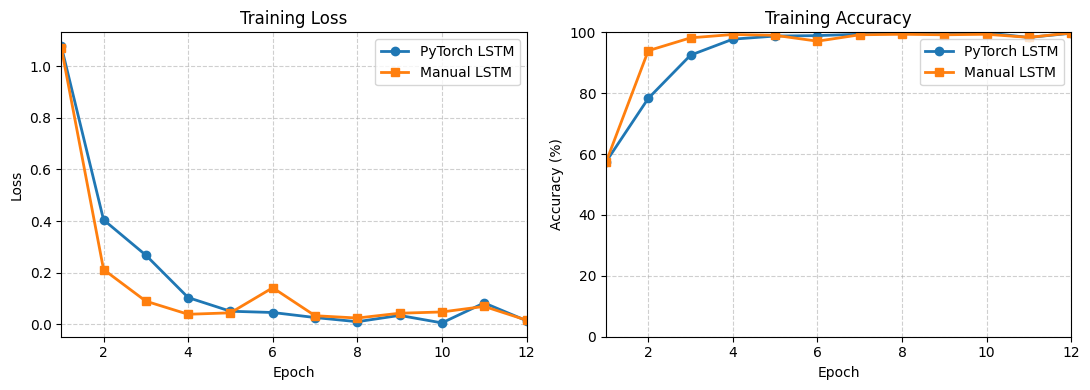

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

epochs_range = range(1, len(torch_train_losses) + 1)

# Loss
axes[0].plot(epochs_range, torch_train_losses, marker='o', linewidth=2, label="PyTorch LSTM")
axes[0].plot(epochs_range, manual_train_losses, marker='s', linewidth=2, label="Manual LSTM")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

# Accuracy
axes[1].plot(epochs_range, [a * 100 for a in torch_train_accs], marker='o', linewidth=2, label="PyTorch LSTM")
axes[1].plot(epochs_range, [a * 100 for a in manual_train_accs], marker='s', linewidth=2, label="Manual LSTM")
axes[1].set_title("Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 100)
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close(fig)

In [17]:
torch_model.eval()
manual_model.eval()

with tc.no_grad():
    torch_loss_sum, torch_acc_sum = 0.0, 0.0
    manual_loss_sum, manual_acc_sum = 0.0, 0.0
    n = 0

    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        # ---- PyTorch model ----
        torch_logits, _ = torch_model(x_batch)
        torch_logits_last = torch_logits[:, -1, :]

        torch_loss = loss_fn(torch_logits_last, y_batch)

        # ---- Manual model ----
        manual_logits, _ = manual_model(x_batch)
        manual_logits_last = manual_logits[:, -1, :]

        manual_loss = loss_fn(manual_logits_last, y_batch)

        # ---- Statistics ----
        B_curr = x_batch.size(0)

        torch_loss_sum += torch_loss.item() * B_curr
        torch_acc_sum  += batch_accuracy(torch_logits_last, y_batch) * B_curr

        manual_loss_sum += manual_loss.item() * B_curr
        manual_acc_sum  += batch_accuracy(manual_logits_last, y_batch) * B_curr

        n += B_curr

torch_test_loss = torch_loss_sum / n
torch_test_acc  = torch_acc_sum / n

manual_test_loss = manual_loss_sum / n
manual_test_acc  = manual_acc_sum / n

print(
    f"PyTorch model | test loss {torch_test_loss:.4f} | test acc {torch_test_acc*100:.2f}%\n"
    f"Manual model  | test loss {manual_test_loss:.4f} | test acc {manual_test_acc*100:.2f}%"
)

PyTorch model | test loss 0.0082 | test acc 99.90%
Manual model  | test loss 0.0695 | test acc 97.36%


## <u>Optional Exploration and Homework</u>

In this notebook we implemented a **many-to-one** sequence model, where the network receives an entire sequence and produces a single output. However, recurrent networks can naturally support several other sequence modeling patterns. If you would like to explore further, consider experimenting with the following ideas:

---

**1. Implement a one-to-many task**

Modify the model so that a **single input produces a sequence of outputs**. For example, you can feed one image or feature vector, or generate a sequence of predictions.

This type of architecture is commonly used in tasks such as image captioning, where one image is used to generate a sequence of words.

Some simple datasets you may try for experimentation:

- **Flickr8k / Flickr30k** – small image captioning datasets  
- **MSCOCO captions** – a larger dataset commonly used for caption generation  

---

**2. Implement a many-to-many task**

Instead of producing only one prediction at the final time step, train the model to **produce an output at every time step**. In this setup the loss is computed across the entire sequence. This type of model is common in tasks such as part-of-speech tagging, speech recognition, frame-level video classification, etc. Some datasets you may want to explore are:

- **Penn Treebank** – classic dataset for language modeling and tagging (we will use it in the last notebook of this tutorial)  
- **IMDB reviews** – sentiment analysis at word level  
- **UCI Human Activity Recognition dataset** – sequence classification from sensor data

### References

1) **Sepp Hochreiter, Jürgen Schmidhuber (1997)**  
   *Long Short-Term Memory*  
   Neural Computation.  
   https://www.bioinf.jku.at/publications/older/2604.pdf

2) **Felix Gers, Jürgen Schmidhuber, Fred Cummins (2000)**  
   *Learning to Forget: Continual Prediction with LSTM*  
   Introduces the forget gate mechanism.  
   https://www.bioinf.jku.at/publications/older/2304.pdf

3) **Christopher Olah (2015)**  
   *Understanding LSTM Networks*  
   A widely used intuitive explanation of LSTM gates and memory flow.  
   https://colah.github.io/posts/2015-08-Understanding-LSTMs/

4) **PyTorch Documentation — LSTM**  
   Official implementation reference for `torch.nn.LSTM`.  
   https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html

5) **Ian Goodfellow, Yoshua Bengio, Aaron Courville (2016)**  
   *Deep Learning*, MIT Press — Chapter 10: Sequence Modeling.  
   https://www.deeplearningbook.org/